In [1]:
import os
# Switch to parent directory
os.chdir("..")
root = os.getcwd()

In [2]:
import sys
sys.path.insert(0, os.path.join(root, "src"))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from spo.models import (
    calibrate_gbm, calibrate_heston_multi,
    simulate_gbm_paths, simulate_heston_paths,
)

log_ret = pd.read_parquet(root + "/data/processed/sp500_log_returns.parquet")
# Calibrate on the most recent 3 years
calibration_window = log_ret.iloc[-756:]
heston_multi = calibrate_heston_multi(calibration_window)
gbm = calibrate_gbm(calibration_window)

# Summary table annualized
rows = []
for ticker, p in heston_multi.assets.items():
    pa = p.annualize()
    rows.append({
        "Ticker": ticker,
        "θ (ann. variance)": pa.theta,
        "√θ (ann. vol)": np.sqrt(pa.theta),
        "κ (ann. MR speed)": pa.kappa,
        "σ (ann. vol-of-vol)": pa.sigma,
        "ρ (leverage)": p.rho,
        "Feller": "not violated" if p.annualize().feller_check else "violated",
    })
summary = pd.DataFrame(rows).set_index("Ticker")
summary.head(10).style.format({
    "θ (ann. variance)": "{:.4f}",
    "√θ (ann. vol)": "{:.2%}",
    "κ (ann. MR speed)": "{:.2f}",
    "σ (ann. vol-of-vol)": "{:.3f}",
    "ρ (leverage)": "{:+.2f}",
})

,θ (ann. variance),√θ (ann. vol),κ (ann. MR speed),σ (ann. vol-of-vol),ρ (leverage),Feller
Ticker,,,,,,
A,0.0766,27.67%,15.00,0.130,-0.40,not violated
AAPL,0.0623,24.96%,15.00,0.142,-0.40,not violated
ABT,0.0390,19.76%,15.00,0.090,-0.40,not violated
ACGL,0.0570,23.88%,15.00,0.110,-0.40,not violated
ACN,0.0604,24.57%,15.00,0.136,-0.40,not violated
ADBE,0.1087,32.98%,15.00,0.225,-0.40,not violated
ADI,0.1030,32.10%,15.00,0.220,-0.40,not violated
ADM,0.0851,29.16%,15.00,0.165,-0.40,not violated
ADP,0.0333,18.26%,15.00,0.108,-0.40,not violated


In [4]:
sim_g = simulate_gbm_paths(gbm, n_paths=5000, n_steps=21, seed=2026)
sim_h = simulate_heston_paths(heston_multi, n_paths=5000, n_steps=21, seed=2026)

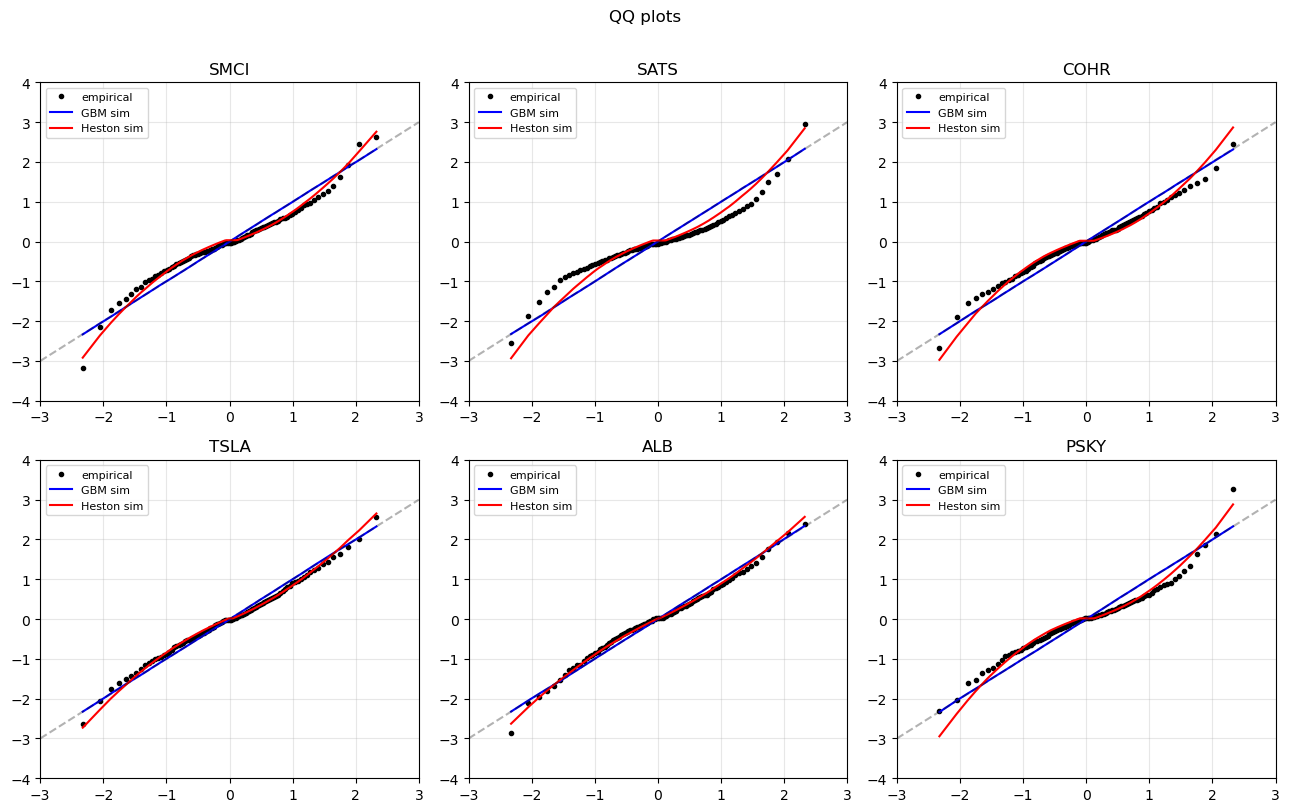

In [5]:
biggest = pd.Series(
    {t: np.sqrt(p.theta * 252) for t, p in heston_multi.assets.items()}
).nlargest(6).index

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, ticker in zip(axes.flat, biggest):
    i = list(heston_multi.tickers).index(ticker)
    emp = calibration_window[ticker].values
    g = sim_g["log_returns"][:, :, i].flatten()
    h = sim_h["log_returns"][:, :, i].flatten()
    # Standardize all three
    emp_std = (emp - emp.mean()) / emp.std()
    g_std = (g - g.mean()) / g.std()
    h_std = (h - h.mean()) / h.std()
    # QQ vs. standard normal quantiles
    q = np.linspace(0.01, 0.99, 99)
    ax.plot(stats.norm.ppf(q), np.quantile(emp_std, q), "ko", ms=3, label="empirical")
    ax.plot(stats.norm.ppf(q), np.quantile(g_std, q), "b-", label="GBM sim")
    ax.plot(stats.norm.ppf(q), np.quantile(h_std, q), "r-", label="Heston sim")
    ax.plot([-3, 3], [-3, 3], "k--", alpha=0.3)
    ax.set_title(ticker); ax.set_xlim(-3, 3); ax.set_ylim(-4, 4)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("QQ plots", y=1.01)
plt.tight_layout(); plt.show()

In [6]:
records = []
for ticker in heston_multi.tickers[:15]:
    i = heston_multi.tickers.index(ticker)
    emp = calibration_window[ticker].values
    g = sim_g["log_returns"][:, :, i].flatten()
    h = sim_h["log_returns"][:, :, i].flatten()
    
    records.append({"Ticker": ticker,
                    "Empirical kurt": pd.Series(emp).kurt(),
                    "GBM kurt": pd.Series(g).kurt(),
                    "Heston kurt": pd.Series(h).kurt()})
kurt_table = pd.DataFrame(records).set_index("Ticker")
kurt_table.style.format("{:.2f}").background_gradient(axis=1, cmap="RdYlGn_r")

,Empirical kurt,GBM kurt,Heston kurt
Ticker,,,
A,4.14,-0.00,3.38
AAPL,12.30,-0.01,4.25
ABT,6.42,0.00,3.38
ACGL,3.68,-0.01,3.28
ACN,5.50,0.01,3.97
ADBE,12.93,-0.02,5.67
ADI,9.77,0.02,5.89
ADM,68.88,-0.01,4.24
ADP,11.36,0.00,4.59


In [7]:
from spo.models.simulate import simulated_moments
from spo.optim import min_var_portfolio

# Simulate moments under each model
_, cov_gbm = simulated_moments(sim_g, heston_multi.tickers)
_, cov_hes = simulated_moments(sim_h, heston_multi.tickers)

# Build synthetic returns matching each cov so we can call the existing solver
def synth_from_cov(cov, n=2000, seed=0):
    L = np.linalg.cholesky(cov.values + 1e-10 * np.eye(len(cov)))
    z = np.random.default_rng(seed).standard_normal((n, len(cov)))
    return pd.DataFrame(z @ L.T, columns=cov.columns)

w_gbm = min_var_portfolio(synth_from_cov(cov_gbm), covariance="sample")
w_hes = min_var_portfolio(synth_from_cov(cov_hes), covariance="sample")

print(f"L1 weight difference: {(w_gbm - w_hes).abs().sum():.4f}")

L1 weight difference: 0.3339
